# Fraud Check Prediction.

Objective: Prediction of the fraud check.

In [ ]:
## importing Libraries/packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data=pd.read_csv('https://raw.githubusercontent.com/Shipra-09/ML-Project-Random-Forest/refs/heads/main/Fraud-Check-data-files/Fraud_check.csv')
data.head()

,Undergrad,Marital.Status,Taxable.Income,City.Population,Work.Experience,Urban
0,NO,Single,68833,50047,10,YES
1,YES,Divorced,33700,134075,18,YES
2,NO,Married,36925,160205,30,YES
3,YES,Single,50190,193264,15,YES
4,NO,Married,81002,27533,28,NO


In [ ]:
# make a copy of data'
df=data.copy()

In [ ]:
df.shape

(600, 6)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Undergrad        600 non-null    object
 1   Marital.Status   600 non-null    object
 2   Taxable.Income   600 non-null    int64 
 3   City.Population  600 non-null    int64 
 4   Work.Experience  600 non-null    int64 
 5   Urban            600 non-null    object
dtypes: int64(3), object(3)
memory usage: 28.3+ KB


In [ ]:
df.describe()

,Taxable.Income,City.Population,Work.Experience
count,600.000000,600.000000,600.000000
mean,55208.375000,108747.368333,15.558333
std,26204.827597,49850.075134,8.842147
min,10003.000000,25779.000000,0.000000
25%,32871.500000,66966.750000,8.000000
50%,55074.500000,106493.500000,15.000000
75%,78611.750000,150114.250000,24.000000
max,99619.000000,199778.000000,30.000000


In [ ]:
df.isnull().sum()

,0
Undergrad,0
Marital.Status,0
Taxable.Income,0
City.Population,0
Work.Experience,0
Urban,0


In [ ]:
df.duplicated().sum()

np.int64(0)

Exploratory data analysis

In [ ]:
df.columns

Index(['Undergrad', 'Marital.Status', 'Taxable.Income', 'City.Population',
       'Work.Experience', 'Urban'],
      dtype='object')

In [ ]:
# changing the Taxable income to categorical one
#taxable_income <= 30000 as "Risky" and others are "Good".
df['Tax_criteria']=df['Taxable.Income'].map(lambda x: "Risky" if x<=30000 else "Good")

In [ ]:

df.head()

,Undergrad,Marital.Status,Taxable.Income,City.Population,Work.Experience,Urban,Tax_criteria
0,NO,Single,68833,50047,10,YES,Good
1,YES,Divorced,33700,134075,18,YES,Good
2,NO,Married,36925,160205,30,YES,Good
3,YES,Single,50190,193264,15,YES,Good
4,NO,Married,81002,27533,28,NO,Good


In [ ]:

# to check the categorical columns
cat_col=df.select_dtypes(np.object_)

In [ ]:

# to check the categorical columns
cat_col=df.select_dtypes(np.object_)
cat_col.head()

,Undergrad,Marital.Status,Urban,Tax_criteria
0,NO,Single,YES,Good
1,YES,Divorced,YES,Good
2,NO,Married,YES,Good
3,YES,Single,YES,Good
4,NO,Married,NO,Good


In [ ]:

# to check the numerical columns
num_col=df.select_dtypes(np.number)
num_col.head()

,Taxable.Income,City.Population,Work.Experience
0,68833,50047,10
1,33700,134075,18
2,36925,160205,30
3,50190,193264,15
4,81002,27533,28


In [ ]:

df.head()

,Undergrad,Marital.Status,Taxable.Income,City.Population,Work.Experience,Urban,Tax_criteria
0,NO,Single,68833,50047,10,YES,Good
1,YES,Divorced,33700,134075,18,YES,Good
2,NO,Married,36925,160205,30,YES,Good
3,YES,Single,50190,193264,15,YES,Good
4,NO,Married,81002,27533,28,NO,Good


In [ ]:

df['Tax_criteria'].value_counts()

,count
Tax_criteria,
Good,476
Risky,124


Number of people with good status are 476
Number of people with risk status are 124

In [ ]:

df.groupby(['Undergrad','Tax_criteria']).size()

Undergrad  Tax_criteria
NO         Good            230
           Risky            58
YES        Good            246
           Risky            66
dtype: int64

1.This does not give any specific information.
2.The count of good and risky status is almost same for people with/not with undergrad background

In [ ]:

df.groupby(['Marital.Status','Tax_criteria']).size()

Marital.Status  Tax_criteria
Divorced        Good            153
                Risky            36
Married         Good            149
                Risky            45
Single          Good            174
                Risky            43
dtype: int64

1.There are large number of Single individuals who have good status, followed by divorced and married.
2.There are large number of married individuals who have risk status, followed by single and divorced.

In [ ]:

df.groupby(['Urban','Tax_criteria']).size()

Urban  Tax_criteria
NO     Good            237
       Risky            61
YES    Good            239
       Risky            63
dtype: int64

1.This does not give any specific information.
2.The count of good and risky status is almost same for people from/not from urban area

Text(0.5, 1.0, 'count of Tax criteria')

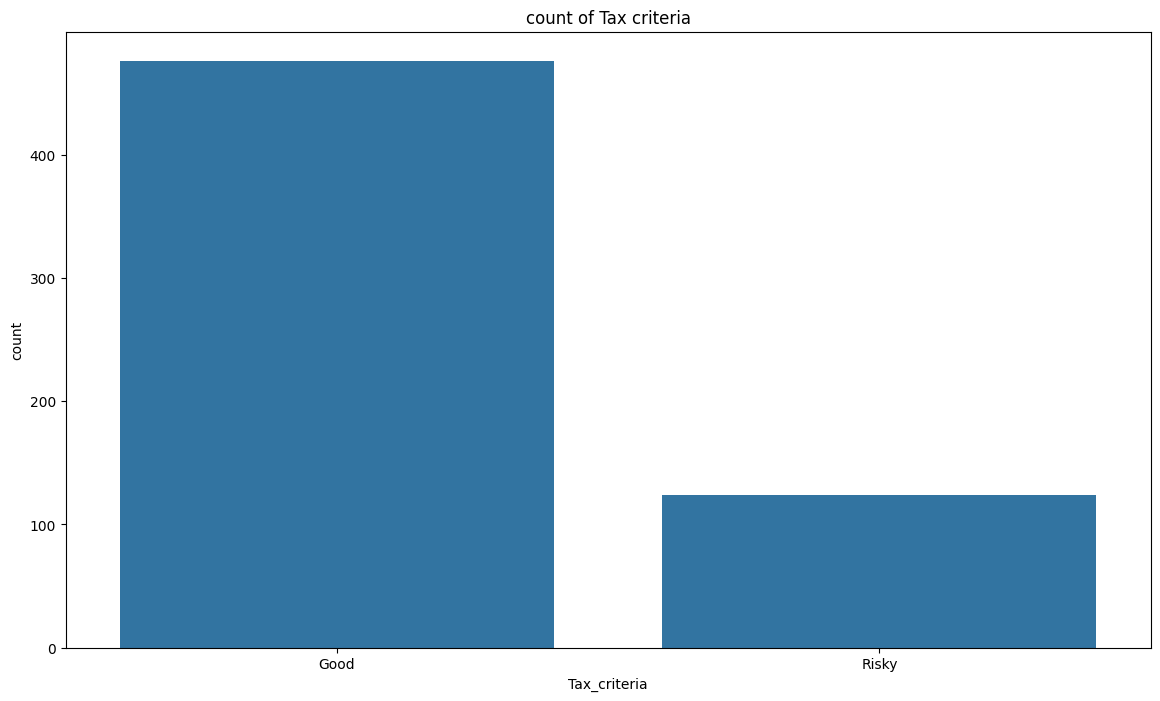

In [ ]:
# marital status wise Tax criteria
plt.figure(figsize=(14,8))
sns.countplot(data=df,x='Tax_criteria')
plt.savefig('Tax criteria count.jpg',bbox_inches='tight',dpi=200)
plt.title('count of Tax criteria')

Text(0.5, 1.0, 'Undergrad wise Tax criteria')

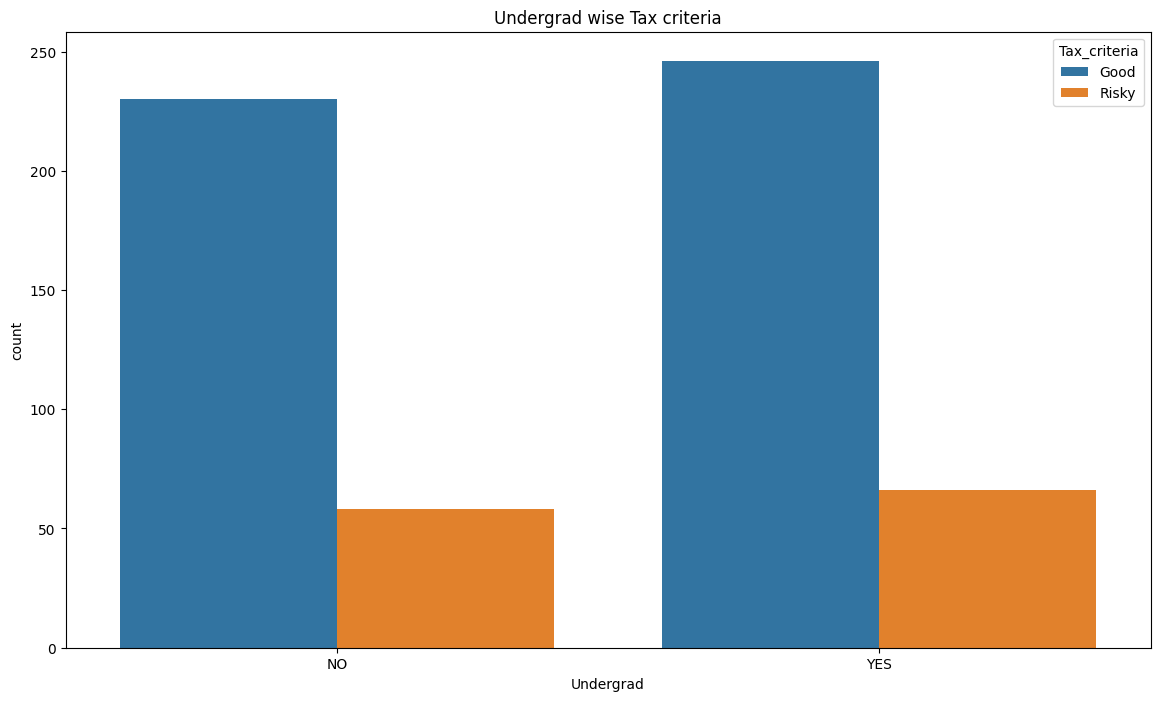

In [ ]:

# Undergrad wise Tax criteria
plt.figure(figsize=(14,8))
sns.countplot(data=df,x='Undergrad',hue='Tax_criteria')
plt.savefig('Undergrad wise Tax criteria.jpg',bbox_inches='tight',dpi=200)
plt.title('Undergrad wise Tax criteria')

Text(0.5, 1.0, 'marital status wise Tax criteria')

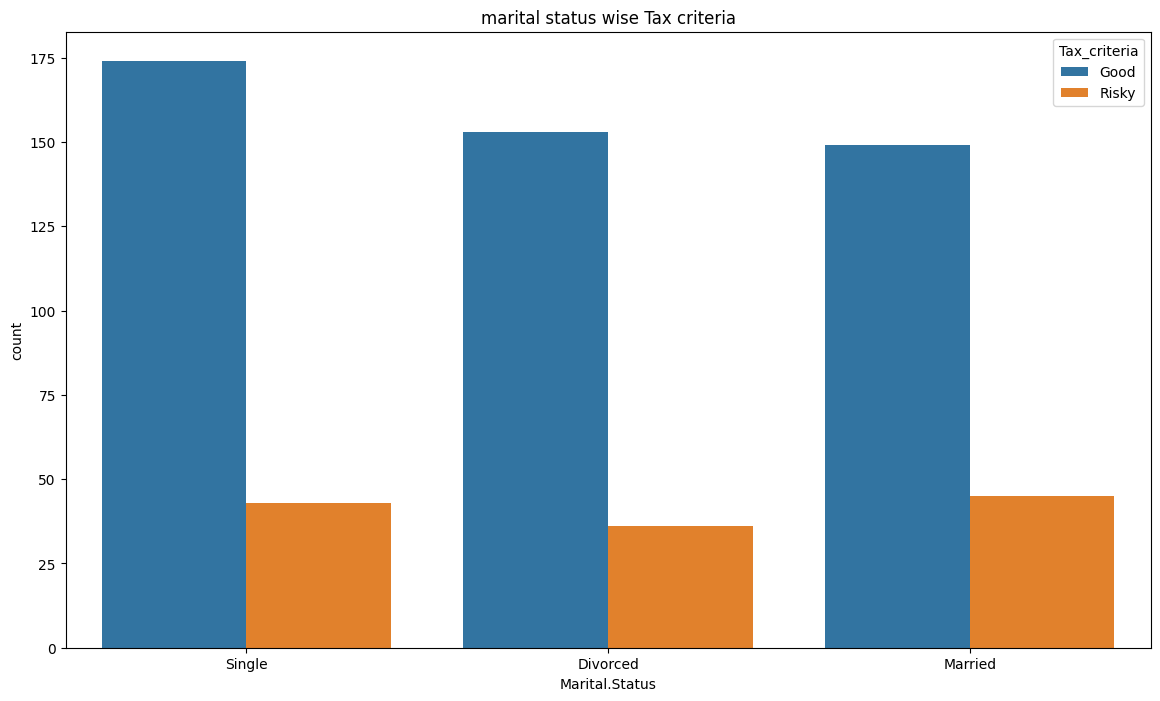

In [ ]:

# marital status wise Tax criteria
plt.figure(figsize=(14,8))
sns.countplot(data=df,x='Marital.Status',hue='Tax_criteria')
plt.savefig('marital status wise Tax criteria.jpg',bbox_inches='tight',dpi=200)
plt.title('marital status wise Tax criteria')

Text(0.5, 1.0, 'Urban wise Tax criteria')

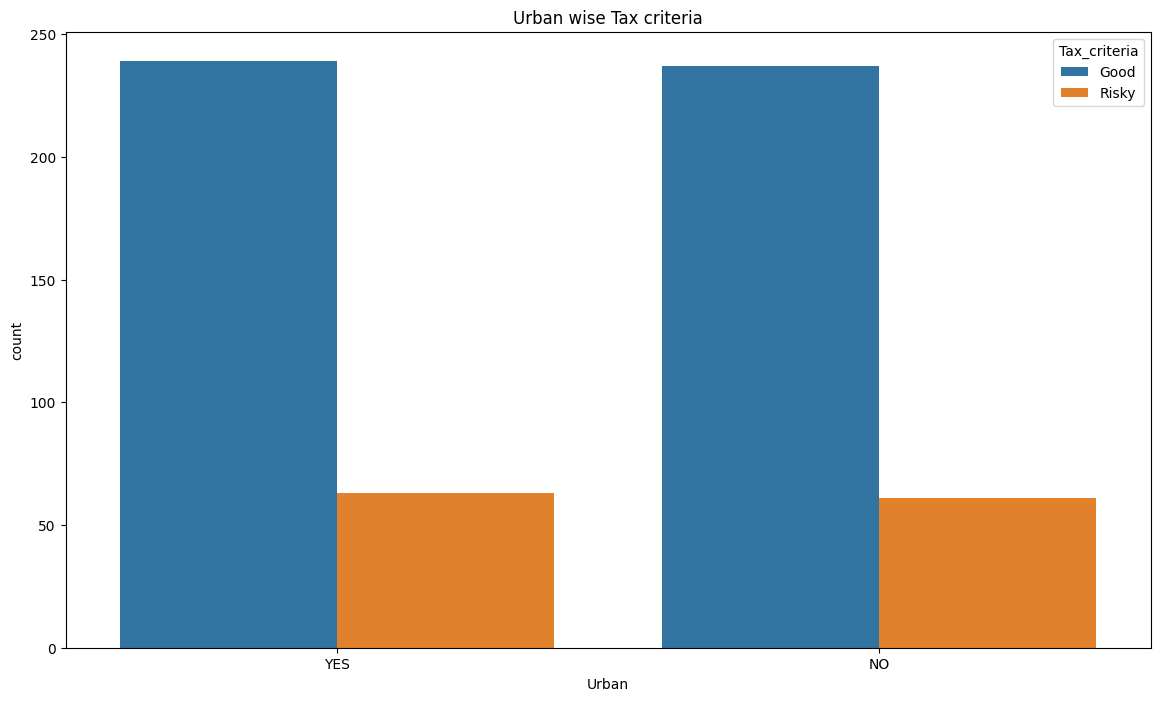

In [ ]:

# Urban wise Tax criteria
plt.figure(figsize=(14,8))
sns.countplot(data=df,x='Urban',hue='Tax_criteria')
plt.savefig('Urban wise Tax criteria.jpg',bbox_inches='tight',dpi=200)
plt.title('Urban wise Tax criteria')

/tmp/ipykernel_3623/4114995871.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[col])
/tmp/ipykernel_3623/4114995871.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[col])
/tmp/ipykernel_3623/4114995871.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in s

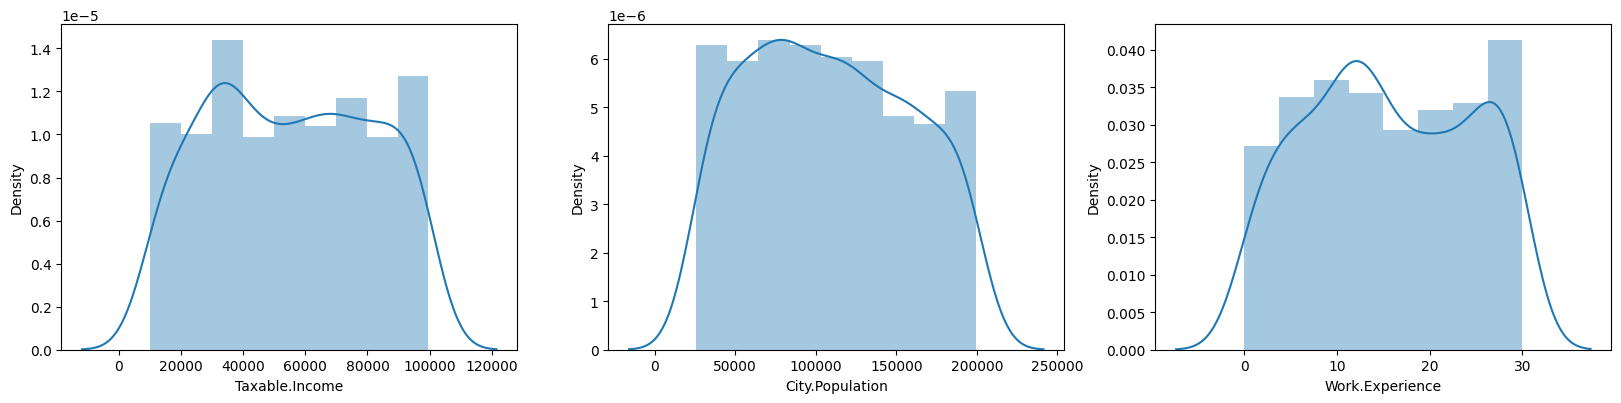

In [ ]:

# A univariate distrubution of numerical features
plt.figure(figsize=(20,60),facecolor='white')
plot_num=1
for col in num_col:
    ax=plt.subplot(12,3,plot_num)
    sns.distplot(df[col])
    plt.xlabel(col)
    plot_num+=1
#plt.title('distribution of',df_num)
plt.savefig('distribution of features.jpg',bbox_inches='tight',dpi=200)
plt.show()


The data in all the features is normally distributed.

In [ ]:
round(df.skew(numeric_only=True),2)

,0
Taxable.Income,0.03
City.Population,0.13
Work.Experience,0.02


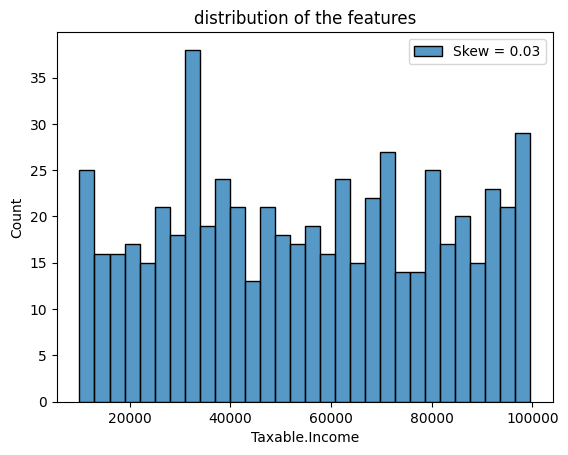

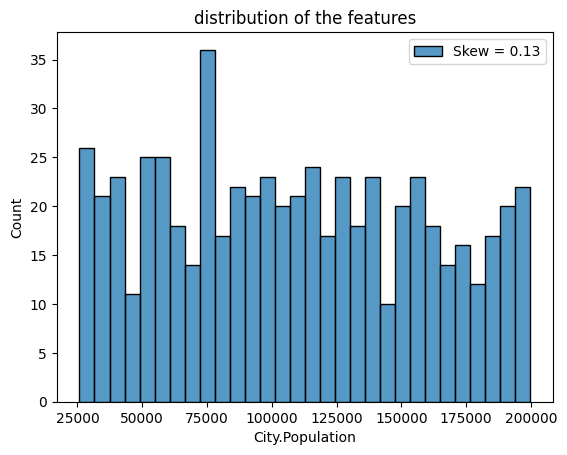

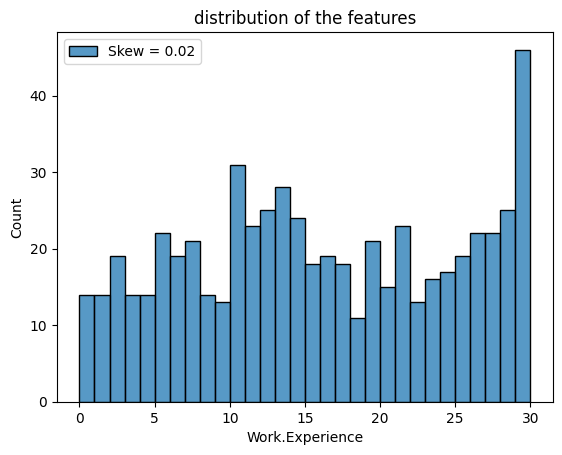

In [ ]:
# -----------------OR----------------
for col in num_col:
    skew = df[col].skew()
    sns.histplot(df[col], kde= False, label='Skew = %.2f' %(skew), bins=30) # Changed distplot to histplot
    plt.legend(loc='best')
    plt.title('distribution of the features')
    plt.savefig('distribution of features.jpg',bbox_inches='tight',dpi=200)
    plt.show()

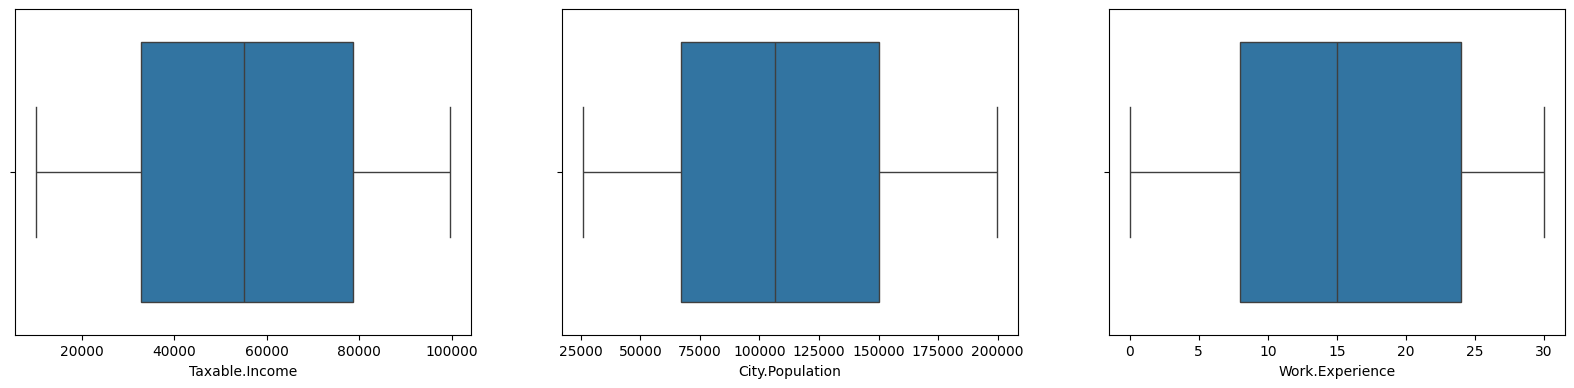

In [ ]:
# A univariate boxplot of numerical features
plt.figure(figsize=(20,60),facecolor='white')
plot_num=1
for col in num_col:
    ax=plt.subplot(12,3,plot_num)
    sns.boxplot(x=df[col])
    plt.xlabel(col)
    plot_num+=1
#plt.title('distribution of',df_num)
plt.savefig('boxplot of features with outliers.jpg')
plt.show()

There are no outliers in the dataset.

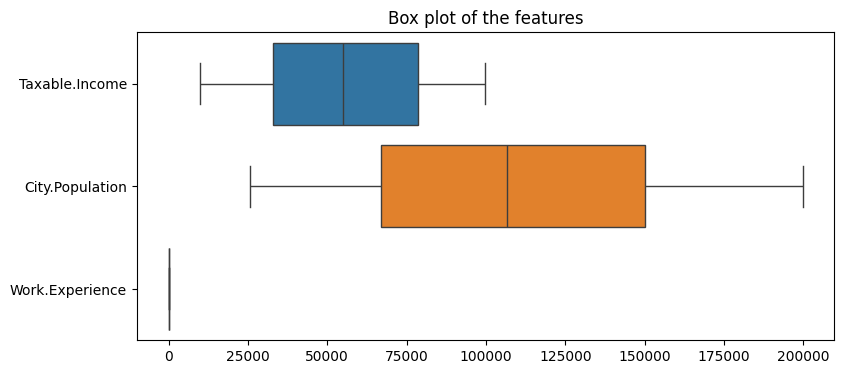

In [ ]:

# ------or------
# Box plot to check the presence of outliers
plt.figure(figsize=(9,4))
sns.boxplot(data= num_col, orient="h")
plt.title('Box plot of the features')
plt.savefig('boxplot of features.jpg',bbox_inches='tight',dpi=200)
plt.show()

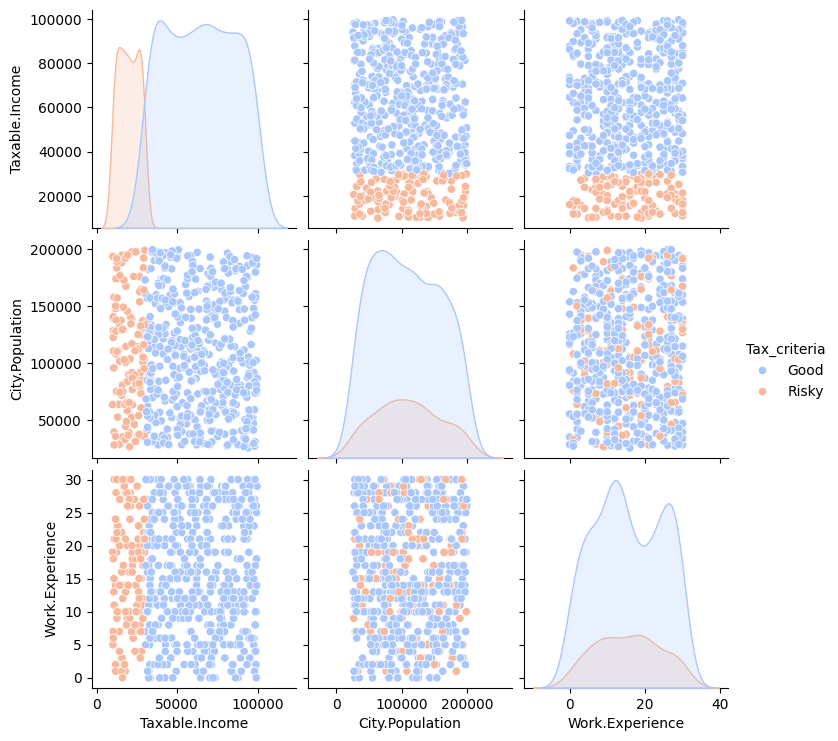

In [ ]:
sns.pairplot(data=df,hue='Tax_criteria', palette='coolwarm')
plt.savefig('pairplot of features.jpg',bbox_inches='tight',dpi=200)
plt.show()

In [ ]:

df.columns

Index(['Undergrad', 'Marital.Status', 'Taxable.Income', 'City.Population',
       'Work.Experience', 'Urban', 'Tax_criteria'],
      dtype='object')

In [ ]:
df.corr(numeric_only=True)

,Taxable.Income,City.Population,Work.Experience
Taxable.Income,1.000000,-0.064387,-0.001818
City.Population,-0.064387,1.000000,0.013135
Work.Experience,-0.001818,0.013135,1.000000


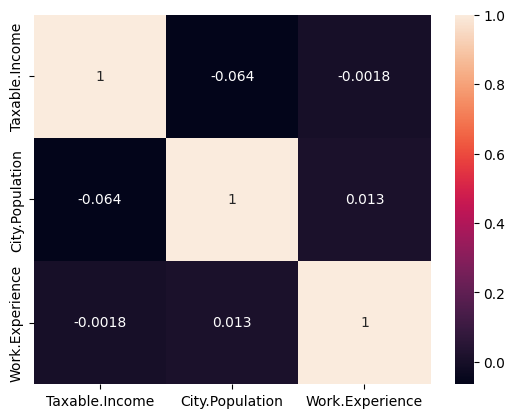

In [ ]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

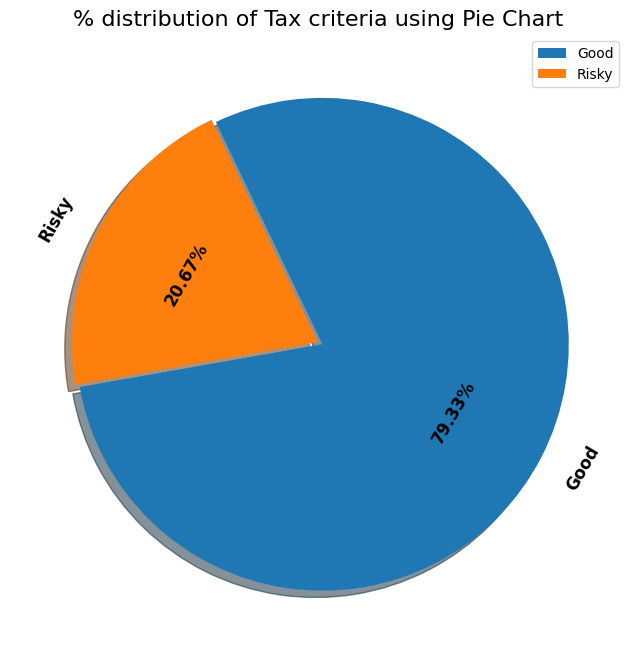

In [ ]:
plt.figure(figsize = (9,8))
plt.pie(df['Tax_criteria'].value_counts(), labels= df['Tax_criteria'].unique(),
       explode = [0.02,0.0], autopct= '%.2f%%', shadow= True, startangle= 190,
       textprops = {'size':'large', 'fontweight':'bold', 'rotation': 60, 'color':'black'})
plt.legend(loc= 'upper right')
plt.title("% distribution of Tax criteria using Pie Chart", fontsize = 16)
plt.savefig('pie chart of Tax criteria.png',bbox_inches='tight',dpi=200)
plt.show()

In [ ]:

cat_col.head()

,Undergrad,Marital.Status,Urban,Tax_criteria
0,NO,Single,YES,Good
1,YES,Divorced,YES,Good
2,NO,Married,YES,Good
3,YES,Single,YES,Good
4,NO,Married,NO,Good


In [ ]:
# let's convert bool value features like undergrad and Urban into numeric one
cat_col['Urban'] = cat_col['Urban'].replace(to_replace={'YES':1, 'NO':0})
cat_col['Undergrad'] = cat_col['Undergrad'].replace(to_replace={'YES':1, 'NO':0})

/tmp/ipykernel_3623/423812711.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cat_col['Urban'] = cat_col['Urban'].replace(to_replace={'YES':1, 'NO':0})
/tmp/ipykernel_3623/423812711.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cat_col['Undergrad'] = cat_col['Undergrad'].replace(to_replace={'YES':1, 'NO':0})


In [ ]:
# OHE FOR ShelveLOc feature
dum=pd.get_dummies(cat_col['Marital.Status'])

In [ ]:
df1=pd.concat([dum,cat_col],axis=1)

In [ ]:

df1.head()

,Divorced,Married,Single,Undergrad,Marital.Status,Urban,Tax_criteria
0,False,False,True,0,Single,1,Good
1,True,False,False,1,Divorced,1,Good
2,False,True,False,0,Married,1,Good
3,False,False,True,1,Single,1,Good
4,False,True,False,0,Married,0,Good


In [ ]:

df1.drop('Marital.Status',axis=1,inplace=True)

In [ ]:
df1.head()

,Divorced,Married,Single,Undergrad,Urban,Tax_criteria
0,False,False,True,0,1,Good
1,True,False,False,1,1,Good
2,False,True,False,0,1,Good
3,False,False,True,1,1,Good
4,False,True,False,0,0,Good


In [ ]:

df2=pd.concat([num_col,df1],axis=1)

In [ ]:

df2.head()

,Taxable.Income,City.Population,Work.Experience,Divorced,Married,Single,Undergrad,Urban,Tax_criteria
0,68833,50047,10,False,False,True,0,1,Good
1,33700,134075,18,True,False,False,1,1,Good
2,36925,160205,30,False,True,False,0,1,Good
3,50190,193264,15,False,False,True,1,1,Good
4,81002,27533,28,False,True,False,0,0,Good


In [ ]:
df2.drop('Taxable.Income',axis=1,inplace=True)

In [ ]:

df2.head()

,City.Population,Work.Experience,Divorced,Married,Single,Undergrad,Urban,Tax_criteria
0,50047,10,False,False,True,0,1,Good
1,134075,18,True,False,False,1,1,Good
2,160205,30,False,True,False,0,1,Good
3,193264,15,False,False,True,1,1,Good
4,27533,28,False,True,False,0,0,Good



Sampling the data

In [ ]:

x=df2.iloc[:,:7]
y=df2.iloc[:,-1:]

In [ ]:

# Standardization of data
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()

In [ ]:

x_sc=sc.fit_transform(x)

In [ ]:

from sklearn.model_selection import train_test_split

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x_sc,y,test_size=0.2, random_state=1)

In [ ]:
x_train.shape,x_test.shape

((480, 7), (120, 7))


Model Building

In [ ]:

from sklearn.ensemble import RandomForestClassifier

In [ ]:
model_rf=RandomForestClassifier(criterion='gini', max_depth=5,random_state=1)

In [ ]:
model_rf.fit(x_train,y_train.values.ravel())
pred=model_rf.predict(x_test)

In [ ]:
model_rf_fit=model_rf.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [ ]:

pred

array(['Good', 'Good', 'Good', 'Good', 'Good', 'Good', 'Good', 'Good',
       'Good', 'Good', 'Good', 'Good', 'Good', 'Good', 'Good', 'Good',
       'Good', 'Good', 'Good', 'Good', 'Good', 'Good', 'Good', 'Good',
       'Good', 'Good', 'Good', 'Good', 'Good', 'Good', 'Good', 'Good',
       'Good', 'Good', 'Good', 'Good', 'Good', 'Good', 'Good', 'Good',
       'Good', 'Good', 'Good', 'Good', 'Good', 'Good', 'Good', 'Good',
       'Good', 'Good', 'Good', 'Good', 'Good', 'Good', 'Good', 'Good',
       'Good', 'Good', 'Good', 'Good', 'Good', 'Good', 'Good', 'Good',
       'Good', 'Good', 'Good', 'Good', 'Good', 'Good', 'Good', 'Good',
       'Good', 'Good', 'Good', 'Good', 'Good', 'Good', 'Good', 'Good',
       'Good', 'Good', 'Good', 'Good', 'Good', 'Good', 'Good', 'Good',
       'Good', 'Good', 'Good', 'Good', 'Good', 'Good', 'Good', 'Good',
       'Good', 'Good', 'Good', 'Good', 'Good', 'Good', 'Good', 'Good',
       'Good', 'Good', 'Good', 'Good', 'Good', 'Good', 'Good', 'Good',
      

In [ ]:
dd=pd.DataFrame(pred,columns=['predicted'])
dd['actual']=y_test.values.ravel()

In [ ]:
# Model Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Accuracy Score
accuracy = accuracy_score(dd['actual'], dd['predicted'])
print(f"Accuracy Score: {accuracy:.2f}")

# Classification Report
print("\nClassification Report:")
print(classification_report(dd['actual'], dd['predicted']))

# Confusion Matrix
conf_matrix = confusion_matrix(dd['actual'], dd['predicted'])
print("\nConfusion Matrix:")
print(conf_matrix)

# Visualize Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Good', 'Risky'], yticklabels=['Good', 'Risky'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.savefig('confusion_matrix.png', bbox_inches='tight', dpi=200)
plt.show()

In [ ]:

dd.head()

,predicted,actual
0,Good,Risky
1,Good,Good
2,Good,Risky
3,Good,Good
4,Good,Good



Model Dynamics

In [ ]:
from sklearn.metrics import r2_score, accuracy_score,confusion_matrix,ConfusionMatrixDisplay,precision_score,classification_report

In [ ]:
print('Model: Random Forest')

print('The accuracy of the model is:',round(accuracy_score(dd['actual'],dd['predicted']),2))
#print('The precision of the model is:',round(precision_score(dd['actual'],dd['predicted']),2))
print('The confusion matrix is :',confusion_matrix(dd['actual'],dd['predicted']))
print('The classification report is :\n',classification_report(dd['actual'],dd['predicted']))

Model: Random Forest
The accuracy of the model is: 0.81
The confusion matrix is : [[97  0]
 [23  0]]
The classification report is :
               precision    recall  f1-score   support

        Good       0.81      1.00      0.89        97
       Risky       0.00      0.00      0.00        23

    accuracy                           0.81       120
   macro avg       0.40      0.50      0.45       120
weighted avg       0.65      0.81      0.72       120



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


<Axes: >

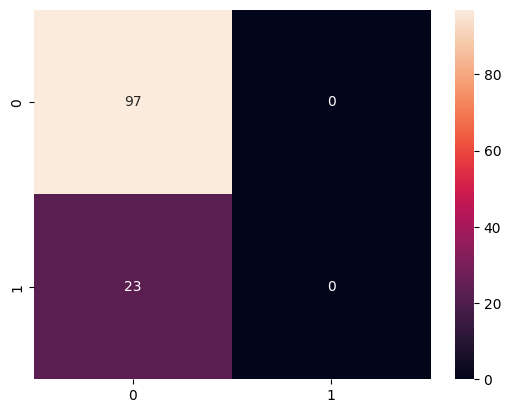

In [ ]:

sns.heatmap(confusion_matrix(y_test,pred), annot=True)


Saving the model

In [ ]:

import joblib

In [ ]:
filename='fraud_check_prj_10.sav'

In [ ]:
joblib.dump(model_rf_fit,filename)

['fraud_check_prj_10.sav']